# This model is trained on (2022/12/01  to  2025/01/01) 25 month data

In [1]:
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")

# If it is available, check how many GPUs are detected
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")

# Check the CUDA version PyTorch was built with
print(f"PyTorch CUDA Version: {torch.version.cuda}")

Is CUDA available? False
PyTorch CUDA Version: None


In [3]:
# ==============================================================================
# STEP-BY-STEP PRE-PROCESSING SCRIPT
# ==============================================================================
import os
import pickle
import xarray as xr
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')
print("--- Starting Full Pre-processing Workflow ---")

# ==============================================================================
# Step 1: Setup and Configuration
# ==============================================================================
print("\n[Step 1/5] Configuring paths and parameters...")

# --- Input and Output Paths ---
# Path to your raw NetCDF file
RAW_DATA_PATH = r'D:\babe_prediction\cmems_mod_ibi_wav_anfc_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.97N_2022-12-01-2025-01-01-001.nc'

# Directory where the clean, processed tensor files will be saved
PROCESSED_DATA_DIR = r'D:\babe_prediction\preprocessing_data_clean'

# --- Model Parameters ---
LOOKBACK_HOURS = 48
FORECAST_HORIZON_HOURS = 24

# --- Feature Engineering ---
# List of variables to use from the .nc file
# Ensure your target variable is also in this list
VARS_TO_USE = ['VCMX','VSDmag', 'VTM10', 'VTM02', 'VTM01_WW', 'VTM01_SW1', 'VMXL', 'VHM0_WW', 'VHM0_SW1']
TARGET_VAR = 'VCMX'

# ==============================================================================
# Step 2: Load and Clean Raw Data
# ==============================================================================
print("\n[Step 2/5] Loading and cleaning raw data...")
try:
    ds_raw = xr.open_dataset(RAW_DATA_PATH)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Raw data file not found at {RAW_DATA_PATH}")

ds_raw['VSDmag'] = np.sqrt(ds_raw['VSDX']**2 + ds_raw['VSDY']**2) 

# --- CRITICAL FIX: Handle the NaN (land mask) values ---
# Convert to float32 for efficiency and fill all NaN values with 0.
# This must be done BEFORE any scaling or processing.
ds_clean = ds_raw[VARS_TO_USE].astype(np.float32).fillna(0)
print("✅ Raw data loaded and NaN values filled with 0.")

# ==============================================================================
# Step 3: Define Data Splits
# ==============================================================================
print("\n[Step 3/5] Splitting data into train, validation, and test sets...")

# Define the date ranges for each split
# Adjust these dates based on the time range of your dataset
ds_train = ds_clean.sel(time=slice('2022-12-01', '2024-06-30'))
ds_val = ds_clean.sel(time=slice('2024-07-01', '2024-09-30'))
ds_test = ds_clean.sel(time=slice('2024-10-01', '2025-01-01'))

# Store splits in a dictionary for easy iteration
ds_splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}

print(f"Train split: {len(ds_train.time)} time steps")
print(f"Validation split: {len(ds_val.time)} time steps")
print(f"Test split: {len(ds_test.time)} time steps")

# ==============================================================================
# Step 4: Create and Save Scalers
# ==============================================================================
print("\n[Step 4/5] Fitting scalers on TRAINING data only...")

scalers = {}
for var in tqdm(VARS_TO_USE, desc="Fitting Scalers"):
    # Reshape data to 2D (time, space) to fit the scaler
    data_to_fit = ds_train[var].values.reshape(-1, 1)
    
    scaler = MinMaxScaler()
    scaler.fit(data_to_fit)
    scalers[var] = scaler

# --- Save the fitted scalers for later use in training and inference ---
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)
print(f"✅ Scalers fitted and saved to '{scaler_path}'")

# ==============================================================================
# Step 5: Process and Save Samples using a Sliding Window
# ==============================================================================
print("\n[Step 5/5] Generating and saving individual samples...")

# Total window size for slicing
total_window_size = LOOKBACK_HOURS + FORECAST_HORIZON_HOURS

for split_name, ds_split in ds_splits.items():
    print(f"\n--- Processing '{split_name}' split ---")
    split_dir = os.path.join(PROCESSED_DATA_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    num_sequences = len(ds_split['time']) - total_window_size
    if num_sequences < 0:
        print(f"⚠️ Warning: '{split_name}' split is too small to create any sequences. Skipping.")
        continue
        
    for i in tqdm(range(num_sequences), desc=f"Saving {split_name} samples"):
        # Define the slice for the current window
        window_slice = ds_split.isel(time=slice(i, i + total_window_size))
        
        # Scale the data in the window
        scaled_window_vars = []
        for var in VARS_TO_USE:
            data = window_slice[var].values
            # Reshape, transform, and reshape back to original dimensions
            scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
            scaled_window_vars.append(scaled_data)
        
        # Stack all variables to create a (time, features, lat, lon) tensor
        # Note: We stack features along a new dimension (axis=1)
        scaled_window_tensor = np.stack(scaled_window_vars, axis=1)

        # Separate into input (X) and target (y)
        X_np = scaled_window_tensor[:LOOKBACK_HOURS, :, :, :]
        y_np = scaled_window_tensor[LOOKBACK_HOURS:, VARS_TO_USE.index(TARGET_VAR), :, :]

        # Convert to PyTorch tensors
        X = torch.from_numpy(X_np.astype(np.float32))
        y = torch.from_numpy(y_np.astype(np.float32))
        
        # Save the sample
        sample_path = os.path.join(split_dir, f'sample_{i:06d}.pt')
        torch.save((X, y), sample_path)

print("\n\n✅ Pre-processing complete!")
print(f"Clean, processed data is now available at: '{PROCESSED_DATA_DIR}'")

--- Starting Full Pre-processing Workflow ---

[Step 1/5] Configuring paths and parameters...

[Step 2/5] Loading and cleaning raw data...
✅ Raw data loaded and NaN values filled with 0.

[Step 3/5] Splitting data into train, validation, and test sets...
Train split: 13872 time steps
Validation split: 2208 time steps
Test split: 2209 time steps

[Step 4/5] Fitting scalers on TRAINING data only...


Fitting Scalers:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Scalers fitted and saved to 'D:\babe_prediction\preprocessing_data_clean\scalers.pkl'

[Step 5/5] Generating and saving individual samples...

--- Processing 'train' split ---


Saving train samples:   0%|          | 0/13800 [00:00<?, ?it/s]


--- Processing 'val' split ---


Saving val samples:   0%|          | 0/2136 [00:00<?, ?it/s]


--- Processing 'test' split ---


Saving test samples:   0%|          | 0/2137 [00:00<?, ?it/s]



✅ Pre-processing complete!
Clean, processed data is now available at: 'D:\babe_prediction\preprocessing_data_clean'


In [ ]:
# ==============================================================================
# CELL 2: TRAINING AND ANALYSIS (RUN EVERY TIME)
# ==============================================================================
import os
import pickle
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# --- Lightweight Dataset (fast and stable) ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# --- Model Architecture ---
# (Model definitions for ConvLSTMCell, ConvLSTM, ConvLSTMNet are unchanged)
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias
        self.padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c):
        h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1)
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n)
        return h_n, c_n

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__()
        self.batch_first, self.num_layers = batch_first, num_layers
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        cell_list = []
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        if not self.batch_first: x = x.permute(1, 0, 2, 3, 4)
        b, s_l, _, h, w = x.size()
        if h_c is None: h_c = self._init_hidden(b, h, w, x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; output_inner = []
            for t in range(s_l):
                h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, b, h, w, d):
        return [cell.init_hidden(b, h, w, d) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__()
        self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True)
        self.output_conv = nn.Conv2d(hidden_dims[1], 1, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq):
        l1_o, _ = self.cl1(x_seq); l2_o, _ = self.cl2(l1_o)
        return self.output_conv(l2_o[:, -1, :, :, :])

# --- Training Function ---
# (Training function definition is unchanged)
def weighted_mse_loss(output, target, weight_threshold=0.8):
    mse = (output - target)**2; weights = torch.where(target > weight_threshold, 2.0, 1.0)
    return torch.mean(weights * mse)

def train_model(model, train_loader, val_loader, device, epochs, lr, model_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = weighted_mse_loss; best_val_loss = float('inf'); scaler = torch.cuda.amp.GradScaler(); patience = 5
    epochs_no_improve = 0; history = {'train_loss': [], 'val_loss': []}
    print("\n--- Starting Model Training ---")
    for epoch in range(epochs):
        start_time = time.time(); model.train(); train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
        for X, y in train_pbar:
            X, y = X.to(device), y.to(device); optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                predicted_step = model(X); target_step = y[:, 0, :, :].unsqueeze(1); loss = loss_fn(predicted_step, target_step)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer); scaler.update(); train_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        avg_train_loss = np.mean([p.get_postfix()['loss'] for p in train_pbar]); model.eval(); total_val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                with torch.cuda.amp.autocast():
                    predicted_step = model(X); target_step = y[:, 0, :, :].unsqueeze(1); loss = loss_fn(predicted_step, target_step)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader); history['train_loss'].append(avg_train_loss); history['val_loss'].append(avg_val_loss)
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - {epoch_time:.1f}s - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss; epochs_no_improve = 0
            model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(model_state, model_path); print(f"✅ New best model saved with validation loss: {best_val_loss:.6f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience: print(f"Early stopping triggered after {epoch+1} epochs."); break
    print(f"\n✅ Training completed. Loading best model from {model_path}")
    best_model_state = torch.load(model_path)
    if isinstance(model, nn.DataParallel): model.module.load_state_dict(best_model_state)
    else: model.load_state_dict(best_model_state)
    return model, history

# --- Main Execution Logic ---

# Configuration
PROCESSED_DATA_DIR = r'D:\babe_prediction\preprocessing_data'
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-5
NUM_WORKERS = 4 
MODEL_SAVE_PATH = 'best_convlstm_model.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create Datasets and DataLoaders
train_dir = os.path.join(PROCESSED_DATA_DIR, 'train')
val_dir = os.path.join(PROCESSED_DATA_DIR, 'val')

train_dataset = PreprocessedWaveDataset(train_dir)
val_dataset = PreprocessedWaveDataset(val_dir)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"DataLoaders created with {NUM_WORKERS} workers. Training will start immediately.")

# Create and Train Model
# CHANGE: The number of input channels is now 11
# (9 time-varying features + 2 static features)
# -------------------------------------------------------------------
input_channels = 11 
# -------------------------------------------------------------------
model = ConvLSTMNet(input_dim=input_channels)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for training.")
    model = nn.DataParallel(model)
model.to(device)
print(f"Model built with {input_channels} input channels.")

trained_model, training_history = train_model(model, train_loader, val_loader, device, EPOCHS, LEARNING_RATE, MODEL_SAVE_PATH)

Using device: cuda
DataLoaders created with 4 workers. Training will start immediately.
Using 2 GPUs for training.
Model built with 11 input channels.

--- Starting Model Training ---


In [2]:
# ==============================================================================
# FINAL TRAINING SCRIPT (using clean data)
# ==============================================================================
import os
import pickle
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# --- Lightweight Dataset to load the pre-processed .pt files ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# --- Model Architecture (Copied from your previous script) ---
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias
        self.padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)

    def forward(self, x, h_c):
        h, c = h_c
        combined = torch.cat([x, h], dim=1)
        cc = self.conv(combined)
        i, f, o, g = torch.split(cc, self.hidden_dim, dim=1)
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
        c_n = f * c + i * g
        h_n = o * torch.tanh(c_n)
        return h_n, c_n

    def init_hidden(self, batch_size, image_size, device):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=device))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__()
        self.batch_first, self.num_layers = batch_first, num_layers
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        cell_list = []
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        self.cell_list = nn.ModuleList(cell_list)

    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size()
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]
            output_inner = []
            for t in range(s_l):
                h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c])
                output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
            
        return cur_in, [h, c]
        
    def _init_hidden(self, batch_size, image_size, device):
        return [cell.init_hidden(batch_size, image_size, device) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__()
        self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True)
        # The output of the model is just the target variable, so 1 channel
        self.output_conv = nn.Conv2d(hidden_dims[1], 1, kernel_size=(1, 1), padding='same')
    
    def forward(self, x_seq):
        # x_seq has shape (batch, lookback, features, lat, lon)
        l1_o, _ = self.cl1(x_seq)
        l2_o, _ = self.cl2(l1_o)
        # We predict based on the last time step of the sequence
        last_time_step_features = l2_o[:, -1, :, :, :]
        # The output will have shape (batch, 1, lat, lon)
        return self.output_conv(last_time_step_features)

# --- Training Function ---
def train_model(model, train_loader, val_loader, device, epochs, lr, model_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss() # Using standard MSE Loss
    best_val_loss = float('inf')
    scaler = torch.cuda.amp.GradScaler()
    patience = 5
    epochs_no_improve = 0
    
    print("\n--- Starting Model Training ---")
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
        for X, y in train_pbar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                predicted = model(X)
                # Target y has shape (batch, forecast_horizon, lat, lon)
                # We are predicting the first step of the horizon
                target = y[:, 0, :, :].unsqueeze(1)
                loss = loss_fn(predicted, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.6f}'})

        avg_train_loss = total_train_loss / len(train_loader)
        
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                with torch.cuda.amp.autocast():
                    predicted = model(X)
                    target = y[:, 0, :, :].unsqueeze(1)
                    loss = loss_fn(predicted, target)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - {epoch_time:.1f}s - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
            print(f"✅ New best model saved with validation loss: {best_val_loss:.6f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break
                
    print(f"\n✅ Training completed. Best model saved to {model_path}")
    model.load_state_dict(torch.load(model_path))
    return model

# ==============================================================================
# --- Main Execution Logic ---
# ==============================================================================

# --- Configuration ---
# IMPORTANT: Point this to the directory with your NEW, CLEAN data
PROCESSED_DATA_DIR = r'D:\babe_prediction\preprocessing_data_clean'
BATCH_SIZE = 4
EPOCHS = 50
LEARNING_RATE = 1e-5 # Start with a safe, lower learning rate
NUM_WORKERS = 0 # Set to 0 for Windows compatibility
MODEL_SAVE_PATH = 'convlstm_on_clean_data.pth' # New name for the new model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Create Datasets and DataLoaders ---
train_dir = os.path.join(PROCESSED_DATA_DIR, 'train')
val_dir = os.path.join(PROCESSED_DATA_DIR, 'val')

train_dataset = PreprocessedWaveDataset(train_dir)
val_dataset = PreprocessedWaveDataset(val_dir)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders created with {len(train_dataset)} training samples and {len(val_dataset)} validation samples.")

# --- Create and Train Model ---
# The number of input channels must match the number of variables in VARS_TO_USE from the pre-processing script.
# ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VTPK', 'VSDX', 'VSDY'] -> 8 variables
INPUT_CHANNELS = 9
model = ConvLSTMNet(input_dim=INPUT_CHANNELS)
model.to(device)
print(f"Model built with {INPUT_CHANNELS} input channels.")

# --- Start Training ---
trained_model = train_model(model, train_loader, val_loader, device, EPOCHS, LEARNING_RATE, MODEL_SAVE_PATH)

Using device: cuda

DataLoaders created with 13800 training samples and 2136 validation samples.
Model built with 9 input channels.

--- Starting Model Training ---


Epoch 1/50 [Training]:   0%|          | 0/3450 [00:00<?, ?it/s]

Epoch 1/50 - 6928.3s - Train Loss: 0.006932 - Val Loss: 0.000773
✅ New best model saved with validation loss: 0.000773


Epoch 2/50 [Training]:   0%|          | 0/3450 [00:00<?, ?it/s]

Epoch 2/50 - 6736.9s - Train Loss: 0.000702 - Val Loss: 0.000270
✅ New best model saved with validation loss: 0.000270


...

Epoch 20/50 - 6760.0s - Train Loss: 0.000021 - Val Loss: 0.000010
✅ New best model saved with validation loss: 0.000010


Epoch 21/50 [Training]:   0%|          | 0/3450 [00:00<?, ?it/s]

Epoch 21/50 - 6769.6s - Train Loss: 0.000021 - Val Loss: 0.000014


Epoch 22/50 [Training]:   0%|          | 0/3450 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
import os
import pickle
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt
import warnings

class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

        
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias
        self.padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)

    def forward(self, x, h_c):
        h, c = h_c
        combined = torch.cat([x, h], dim=1)
        cc = self.conv(combined)
        i, f, o, g = torch.split(cc, self.hidden_dim, dim=1)
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
        c_n = f * c + i * g
        h_n = o * torch.tanh(c_n)
        return h_n, c_n

    def init_hidden(self, batch_size, image_size, device):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=device))
        
class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__()
        self.batch_first, self.num_layers = batch_first, num_layers
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        cell_list = []
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        self.cell_list = nn.ModuleList(cell_list)

    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size()
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]
            output_inner = []
            for t in range(s_l):
                h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c])
                output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
            
        return cur_in, [h, c]
        
    def _init_hidden(self, batch_size, image_size, device):
        return [cell.init_hidden(batch_size, image_size, device) for cell in self.cell_list]

        
class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__()
        self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True)
        # The output of the model is just the target variable, so 1 channel
        self.output_conv = nn.Conv2d(hidden_dims[1], 1, kernel_size=(1, 1), padding='same')
    
    def forward(self, x_seq):
        # x_seq has shape (batch, lookback, features, lat, lon)
        l1_o, _ = self.cl1(x_seq)
        l2_o, _ = self.cl2(l1_o)
        # We predict based on the last time step of the sequence
        last_time_step_features = l2_o[:, -1, :, :, :]
        # The output will have shape (batch, 1, lat, lon)
        return self.output_conv(last_time_step_features)

--- Starting Final Evaluation on the Test Set ---
✅ Best model loaded successfully.

--- Generating predictions for the test set... ---


Evaluating Test Set:   0%|          | 0/535 [00:00<?, ?it/s]


📊 Test Results:
  RMSE: 0.3412
  MAE:  0.3879

--- Generating Visualization 1: Comparison Maps ---


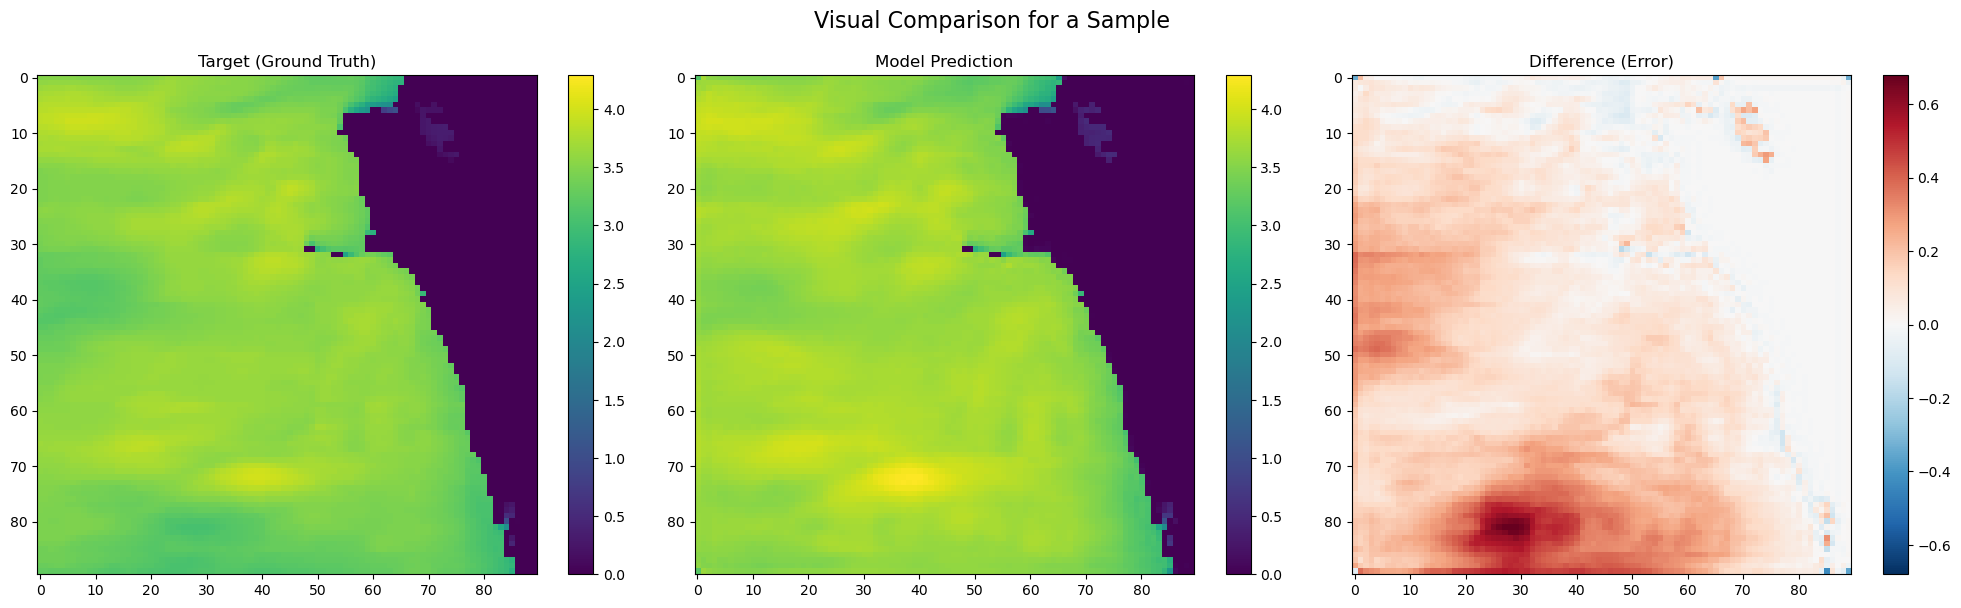

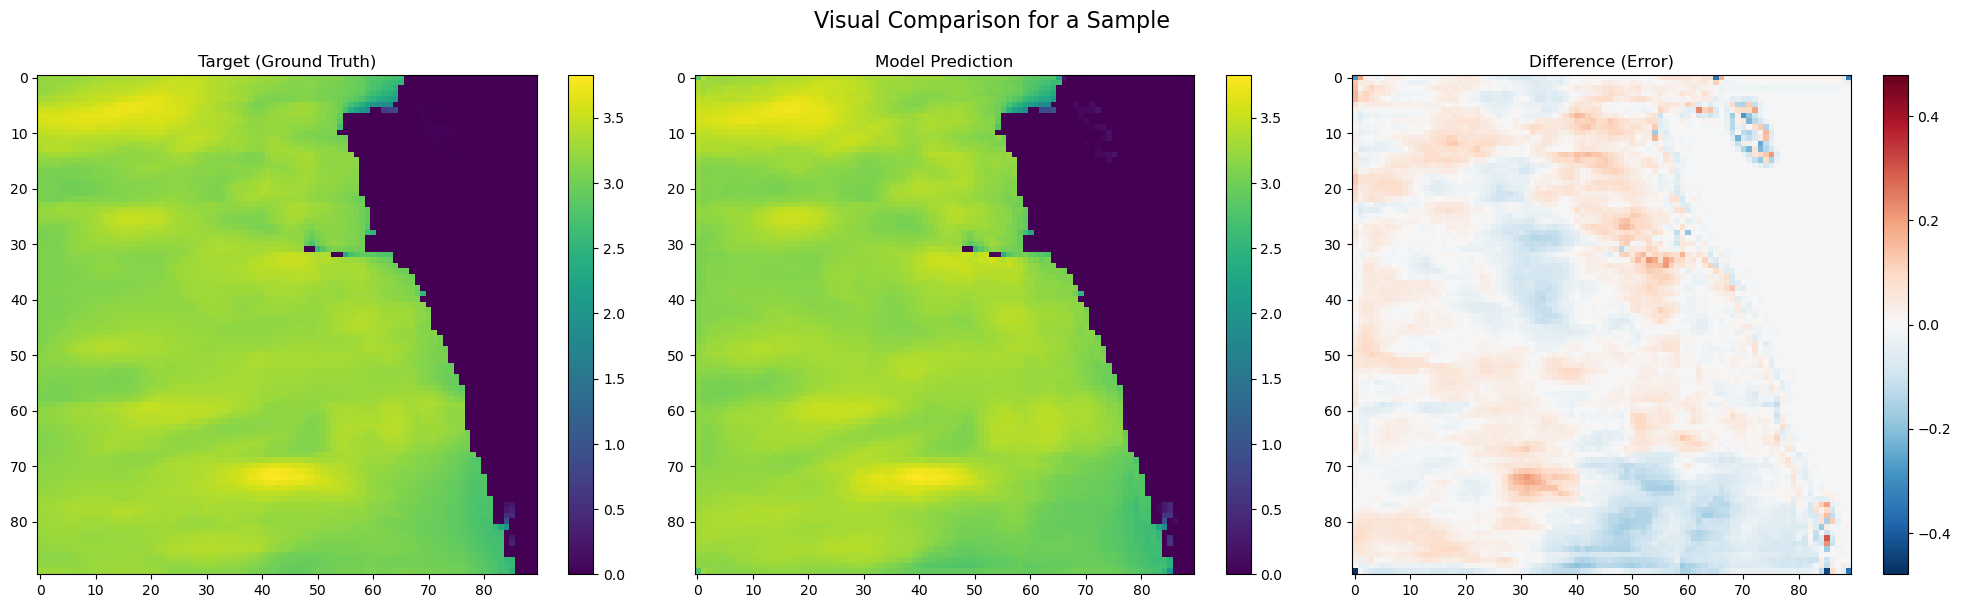

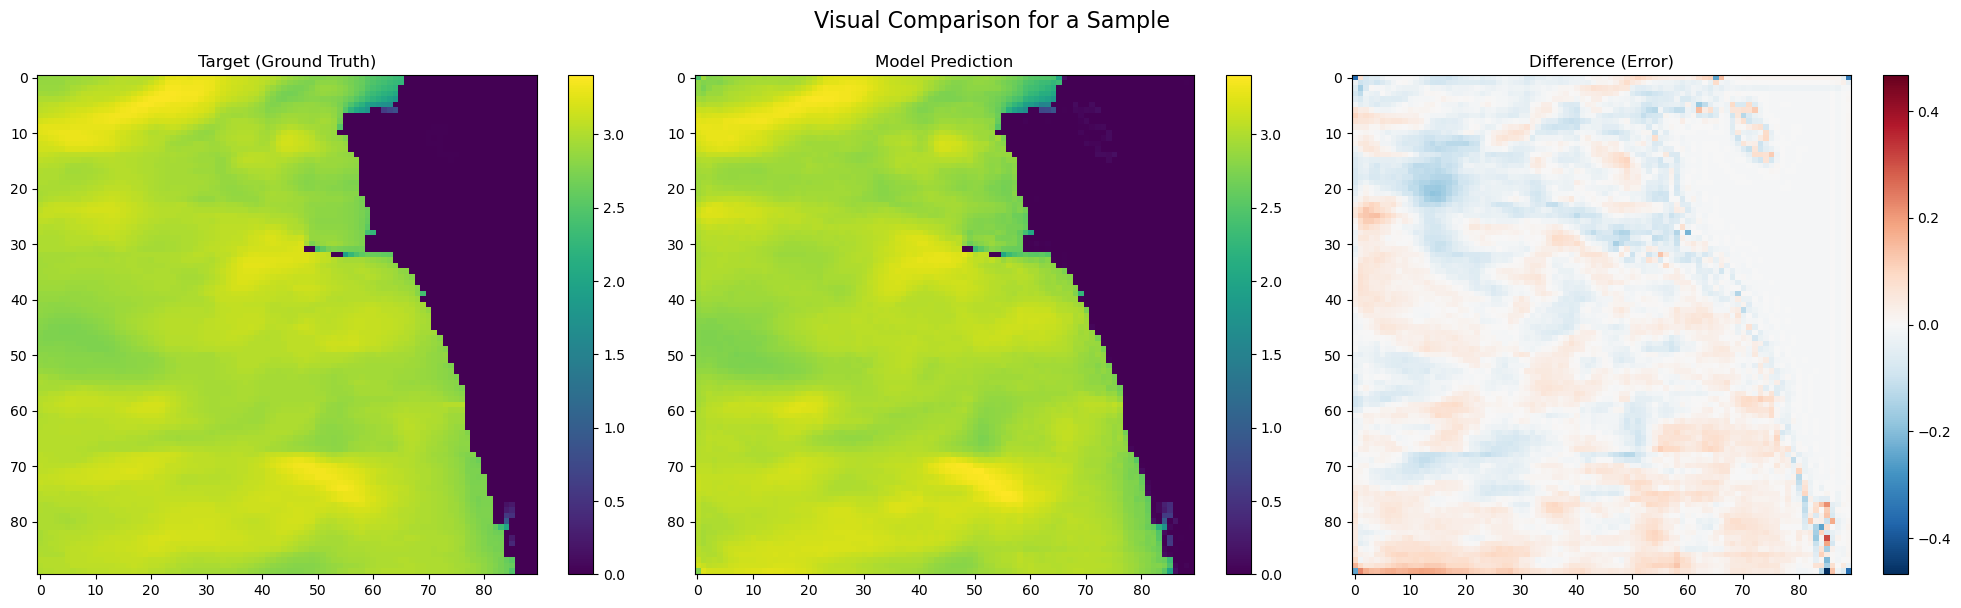

✅ Comparison maps saved to 'test_comparison_X.png'

--- Generating Visualization 2: Scatter Plot ---


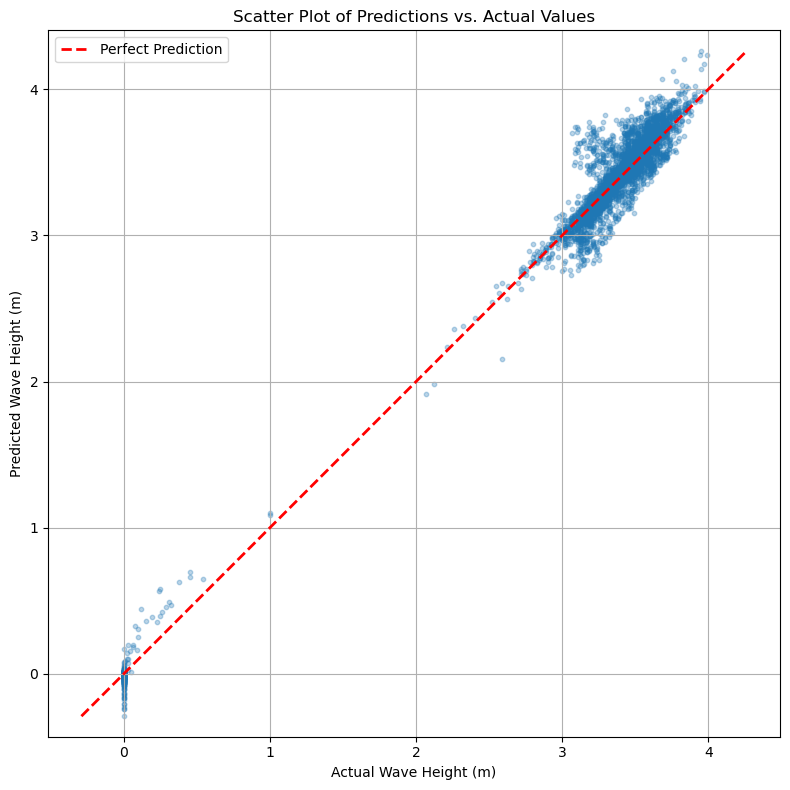

✅ Scatter plot saved to 'scatter_plot.png'

--- Generating Visualization 3: Error Histogram ---


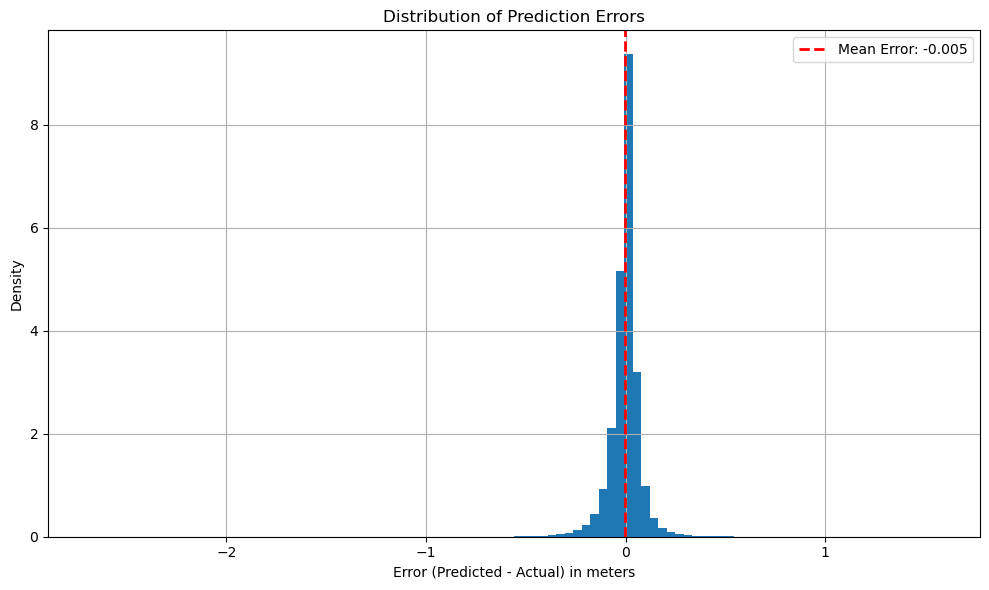

✅ Error histogram saved to 'error_histogram.png'
✅ All validation visualizations are complete.


In [11]:
# ==============================================================================
# FINAL STEP: EVALUATION AND VISUALIZATION ON THE TEST SET
# ==============================================================================
import warnings

# This line tells Python to ignore all warning messages
warnings.filterwarnings('ignore')


import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import pickle
import glob
from torch.utils.data import Dataset, DataLoader

print("--- Starting Final Evaluation on the Test Set ---")

# --- 1. Define All Necessary Classes ---

class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias
        self.padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c):
        h, c = h_c
        combined = torch.cat([x, h], dim=1)
        cc = self.conv(combined)
        i, f, o, g = torch.split(cc, self.hidden_dim, dim=1)
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
        c_n = f * c + i * g
        h_n = o * torch.tanh(c_n)
        return h_n, c_n
    def init_hidden(self, batch_size, image_size, device):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=device))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__()
        self.batch_first, self.num_layers = batch_first, num_layers
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        cell_list = []
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size()
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]
            output_inner = []
            for t in range(s_l):
                h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c])
                output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, batch_size, image_size, device):
        return [cell.init_hidden(batch_size, image_size, device) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__()
        self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True)
        self.output_conv = nn.Conv2d(hidden_dims[1], 1, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq):
        l1_o, _ = self.cl1(x_seq)
        l2_o, _ = self.cl2(l1_o)
        return self.output_conv(l2_o[:, -1, :, :, :])

# --- 2. Load Best Model and Prepare Test Loader ---

# Define configuration
PROCESSED_DATA_DIR = r'D:\babe_prediction\preprocessing_data_clean'
MODEL_SAVE_PATH = 'convlstm_on_clean_data.pth'
BATCH_SIZE = 4
NUM_WORKERS = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the scalers to un-normalize the data for visualization
try:
    with open(os.path.join(PROCESSED_DATA_DIR, 'scalers.pkl'), 'rb') as f:
        scalers = pickle.load(f)
except FileNotFoundError:
    print(f"Error: Scalers file not found at {os.path.join(PROCESSED_DATA_DIR, 'scalers.pkl')}")
    exit()

# Create the test dataset and loader
test_dir = os.path.join(PROCESSED_DATA_DIR, 'test')
if not os.path.exists(test_dir):
    print(f"Error: Test data directory not found at {test_dir}")
    exit()
test_dataset = PreprocessedWaveDataset(test_dir)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Load the trained model
input_channels = 9 
model = ConvLSTMNet(input_dim=input_channels)

try:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    exit()

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for evaluation.")
    model = nn.DataParallel(model)

model.to(device)
model.eval()
print("✅ Best model loaded successfully.")

# --- 3. Memory-Efficient Evaluation and Visualization ---

def evaluate_and_visualize(model, test_loader, device, scalers, target_var):
    model.eval()
    
    # For metrics
    total_rmse_sum_sq, total_mae_sum = 0, 0
    total_samples = 0
    
    # To store a small sample for plotting
    vis_samples_to_plot = 3
    vis_data = {'predictions': [], 'targets': [], 'inputs': []}
    
    print("\n--- Generating predictions for the test set... ---")
    with torch.no_grad():
        for i, (X, y) in enumerate(tqdm(test_loader, desc="Evaluating Test Set")):
            X, y = X.to(device), y.to(device)
            predictions_scaled = model(X)
            
            # For metrics
            target_scaled = y[:, 0, :, :]
            target_scaler = scalers[target_var]
            
            pred_original = target_scaler.inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1)).reshape(predictions_scaled.shape)
            target_original = target_scaler.inverse_transform(target_scaled.cpu().numpy().reshape(-1, 1)).reshape(target_scaled.shape)
            
            total_rmse_sum_sq += np.sum((pred_original - target_original) ** 2)
            total_mae_sum += np.sum(np.abs(pred_original - target_original))
            total_samples += pred_original.size
            
            # Collect a small number of samples for visualization
            if len(vis_data['predictions']) < vis_samples_to_plot:
                vis_data['predictions'].append(pred_original[0].squeeze())
                vis_data['targets'].append(target_original[0].squeeze())
                # Get the VHM0_WW input for context, assuming it's one of the input channels
                # The channel index for VHM0_WW is typically 3 (0-indexed) based on the original list
                vis_data['inputs'].append(X[0, -1, 3, :, :].cpu().numpy())

    rmse = np.sqrt(total_rmse_sum_sq / total_samples)
    mae = total_mae_sum / total_samples
    print(f"\n📊 Test Results:\n  RMSE: {rmse:.4f}\n  MAE:  {mae:.4f}")
    
    return vis_data

vis_data = evaluate_and_visualize(model, test_loader, device, scalers, 'VCMX')


# --- 4. Visualizations (Updated to use collected samples) ---

def plot_visual_comparison(vis_data, save_path):
    for i in range(len(vis_data['predictions'])):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        plt.suptitle(f"Visual Comparison for a Sample", fontsize=16)
        
        pred_sample = vis_data['predictions'][i]
        targ_sample = vis_data['targets'][i]
        v_max = max(np.max(pred_sample), np.max(targ_sample))
        
        im1 = axes[0].imshow(targ_sample, cmap='viridis', vmin=0, vmax=v_max)
        axes[0].set_title('Target (Ground Truth)'); fig.colorbar(im1, ax=axes[0])
        
        im2 = axes[1].imshow(pred_sample, cmap='viridis', vmin=0, vmax=v_max)
        axes[1].set_title('Model Prediction'); fig.colorbar(im2, ax=axes[1])
        
        diff = pred_sample - targ_sample
        diff_max = np.max(np.abs(diff))
        im3 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-diff_max, vmax=diff_max)
        axes[2].set_title('Difference (Error)'); fig.colorbar(im3, ax=axes[2])
        
        plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.savefig(f"{save_path}_{i}.png", dpi=300); plt.show()
    print(f"✅ Comparison maps saved to '{save_path}_X.png'")

# --- Plot Comparison Maps ---
print("\n--- Generating Visualization 1: Comparison Maps ---")
plot_visual_comparison(vis_data, save_path='test_comparison')

# --- Plot Scatter Plot (Requires getting a small, random sample of data) ---
# This part can still be memory-intensive if you try to get too many points.
# A better approach is to sample a small number of points from each batch.
print("\n--- Generating Visualization 2: Scatter Plot ---")
num_points_to_plot = 5000
all_preds_flat, all_targets_flat = [], []

with torch.no_grad():
    for X, y in test_loader:
        if len(all_preds_flat) >= num_points_to_plot:
            break
        X, y = X.to(device), y.to(device)
        predictions_scaled = model(X)
        target_scaled = y[:, 0, :, :]
        
        pred_original = scalers['VCMX'].inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1)).flatten()
        target_original = scalers['VCMX'].inverse_transform(target_scaled.cpu().numpy().reshape(-1, 1)).flatten()
        
        sample_indices = np.random.choice(len(pred_original), min(len(pred_original), num_points_to_plot - len(all_preds_flat)), replace=False)
        all_preds_flat.extend(pred_original[sample_indices])
        all_targets_flat.extend(target_original[sample_indices])

plt.figure(figsize=(8, 8))
plt.scatter(all_targets_flat, all_preds_flat, alpha=0.3, s=10)
min_val = min(min(all_targets_flat), min(all_preds_flat))
max_val = max(max(all_targets_flat), max(all_preds_flat))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Wave Height (m)"); plt.ylabel("Predicted Wave Height (m)")
plt.title("Scatter Plot of Predictions vs. Actual Values")
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=300); plt.show()
print("✅ Scatter plot saved to 'scatter_plot.png'")

# --- Plot Error Histogram ---
print("\n--- Generating Visualization 3: Error Histogram ---")
# To make this memory-efficient, we collect all errors in a list and then plot
all_errors = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        predictions_scaled = model(X)
        target_scaled = y[:, 0, :, :]
        pred_original = scalers['VCMX'].inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1))
        target_original = scalers['VCMX'].inverse_transform(target_scaled.cpu().numpy().reshape(-1, 1))
        all_errors.extend((pred_original - target_original).flatten())

error = np.array(all_errors)
mean_error = np.mean(error)
plt.figure(figsize=(10, 6))
plt.hist(error, bins=100, density=True)
plt.axvline(mean_error, color='r', linestyle='--', lw=2, label=f'Mean Error: {mean_error:.3f}')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Predicted - Actual) in meters"); plt.ylabel("Density")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('error_histogram.png', dpi=300); plt.show()
print("✅ Error histogram saved to 'error_histogram.png'")
print("✅ All validation visualizations are complete.")